# Практичне заняття №2 | Muraviov Nikita
## Реалізація прямого ланцюжка міркувань у Python

**Предметна область:** Помічник із вибору конфігурації ПК/Ноутбука

**Завдання до практичної роботи:**
1. Представити факти та правила у структурах даних Python.
2. Реалізувати механізм перевірки умов правила.
3. Реалізувати алгоритм прямого ланцюжка міркувань.
4. Організувати журнал спрацювань правил.
5. Протестувати систему на власних сценаріях.
6. Надати графічну інтерпретацію всім сценаріям реалізації алгоритму прямого ланцюжка міркувань.
7. Проаналізувати отримані результати та зробити висновки.

In [5]:
# Службові імпорти
import matplotlib.pyplot as plt
import networkx as nx
from pprint import pprint

## Завдання 1. Представити факти та правила у структурах даних Python

Факти описують профіль конкретного користувача через атрибути:
- `primary_goal` — основна мета використання ПК
- `budget` — бюджет покупця
- `mobility` — потреба у мобільності
- `priority` — головний пріоритет
- `os_preference` — перевага щодо операційної системи

Висновки системи: `form_factor`, `device_class`, `recommended_os`

In [21]:
# Завдання 1. Факти та правила

# Початковий приклад фактів одного користувача
facts_example = {
    "primary_goal": "gaming",
    "budget": "high",
    "mobility": "no",
    "priority": "performance",
    "os_preference": "windows"
}

# База правил.
# Формат:
# {
#   "name": "R1",
#   "conditions": {"атрибут": "значення", ...},
#   "conclusion": ("новий_атрибут", "нове_значення")
# }

rules = [
    # --- Визначення form_factor ---
    {"name": "R1",
     "conditions": {"mobility": "yes"},
     "conclusion": ("form_factor", "laptop")},

    {"name": "R2",
     "conditions": {"mobility": "no"},
     "conclusion": ("form_factor", "desktop")},

    {"name": "R3",
     "conditions": {"mobility": "no", "priority": "portability"},
     "conclusion": ("form_factor", "mini_pc")},

    # --- Визначення device_class: ігрові ---
    {"name": "R4",
     "conditions": {"primary_goal": "gaming", "form_factor": "desktop", "budget": "high"},
     "conclusion": ("device_class", "premium_gaming_pc")},

    {"name": "R5",
     "conditions": {"primary_goal": "gaming", "form_factor": "laptop", "budget": "high"},
     "conclusion": ("device_class", "gaming_laptop")},

    {"name": "R6",
     "conditions": {"primary_goal": "gaming", "budget": "low"},
     "conclusion": ("device_class", "budget_gaming_pc")},

    # --- Визначення device_class: офісні ---
    {"name": "R7",
     "conditions": {"primary_goal": "office", "form_factor": "laptop", "budget": "low"},
     "conclusion": ("device_class", "budget_office_laptop")},

    {"name": "R8",
     "conditions": {"primary_goal": "office", "priority": "portability", "form_factor": "laptop", "budget": "medium"},
     "conclusion": ("device_class", "ultrabook")},

    # --- Визначення device_class: творчі ---
    {"name": "R9",
     "conditions": {"primary_goal": "design_video", "os_preference": "macos", "form_factor": "laptop"},
     "conclusion": ("device_class", "macbook_pro")},

    {"name": "R10",
     "conditions": {"primary_goal": "design_video", "form_factor": "desktop", "budget": "high"},
     "conclusion": ("device_class", "professional_workstation")},

    # --- Визначення device_class: домашні ---
    {"name": "R11",
     "conditions": {"primary_goal": "basic_home", "form_factor": "laptop", "priority": "battery_life"},
     "conclusion": ("device_class", "chromebook_or_basic_laptop")},

    {"name": "R12",
     "conditions": {"primary_goal": "basic_home", "form_factor": "desktop", "budget": "low"},
     "conclusion": ("device_class", "budget_home_desktop")},

    # --- Визначення recommended_os ---
    {"name": "R13",
     "conditions": {"device_class": "macbook_pro"},
     "conclusion": ("recommended_os", "macos")},

    {"name": "R14",
     "conditions": {"device_class": "premium_gaming_pc"},
     "conclusion": ("recommended_os", "windows")},

    {"name": "R15",
     "conditions": {"device_class": "gaming_laptop"},
     "conclusion": ("recommended_os", "windows")},

    {"name": "R16",
     "conditions": {"device_class": "professional_workstation"},
     "conclusion": ("recommended_os", "windows_or_linux")},

    {"name": "R17",
     "conditions": {"device_class": "ultrabook"},
     "conclusion": ("recommended_os", "windows")},
]

print("Приклад початкових фактів:")
pprint(facts_example)
print("\nКількість правил:", len(rules))
print("Перші 3 правила:")
pprint(rules[:3])

Приклад початкових фактів:
{'budget': 'high',
 'mobility': 'no',
 'os_preference': 'windows',
 'primary_goal': 'gaming',
 'priority': 'performance'}

Кількість правил: 17
Перші 3 правила:
[{'conclusion': ('form_factor', 'laptop'),
  'conditions': {'mobility': 'yes'},
  'name': 'R1'},
 {'conclusion': ('form_factor', 'desktop'),
  'conditions': {'mobility': 'no'},
  'name': 'R2'},
 {'conclusion': ('form_factor', 'mini_pc'),
  'conditions': {'mobility': 'no', 'priority': 'portability'},
  'name': 'R3'}]


## Завдання 2. Реалізувати механізм перевірки умов правила

Функція `check_conditions` перевіряє, чи всі умови конкретного правила
виконуються для поточного набору фактів.

In [20]:
# Завдання 2. Перевірка умов одного правила

def check_conditions(facts, conditions):
    """
    Повертає True, якщо всі умови правила виконуються у поточних фактах.
    Повертає False, якщо хоча б одна умова не виконана.
    """
    for key, value in conditions.items():
        if facts.get(key) != value:
            return False
    return True

# Перевірка функції на прикладі правила R2 (mobility=no → desktop)
print("Чи спрацьовує R2 для facts_example?")
print(check_conditions(facts_example, rules[1]["conditions"]))

# Перевірка правила R1 (mobility=yes) — має бути False для нашого прикладу
print("Чи спрацьовує R1 для facts_example?")
print(check_conditions(facts_example, rules[0]["conditions"]))

Чи спрацьовує R2 для facts_example?
True
Чи спрацьовує R1 для facts_example?
False


## Завдання 3. Реалізувати алгоритм прямого ланцюжка міркувань

Алгоритм:
1. Бере початкові факти
2. Перевіряє всі правила за допомогою `check_conditions`
3. Якщо правило спрацьовує, додає новий факт до робочої пам'яті
4. Повторює процес, поки з'являються нові факти

## Завдання 4. Організувати журнал спрацювань правил

Журнал спрацювань реалізовано всередині `forward_chain`. Для кожного
спрацювання зберігаємо: номер ітерації, назву правила, умови, висновок.

In [19]:
# Завдання 3 і 4. Прямий ланцюжок міркувань і журнал спрацювань

def forward_chain(facts, rules, max_iterations=10):
    """
    Реалізація алгоритму прямого ланцюжка міркувань.

    Параметри:
        facts          - початкові факти (словник)
        rules          - база правил (список словників)
        max_iterations - максимальна кількість ітерацій (захист від циклів)

    Повертає:
        expanded_facts - факти після прямого висновку
        fired_log      - журнал спрацювань правил
    """
    # Копіюємо початкові факти, щоб не змінювати оригінальний словник
    expanded_facts = dict(facts)

    # Журнал усіх спрацювань
    fired_log = []

    for iteration in range(1, max_iterations + 1):
        changed = False

        # Перебираємо всі правила
        for rule in rules:
            if check_conditions(expanded_facts, rule["conditions"]):
                out_key, out_value = rule["conclusion"]

                # Додаємо лише якщо висновок новий
                if expanded_facts.get(out_key) != out_value:
                    expanded_facts[out_key] = out_value
                    changed = True

                    # Фіксуємо спрацювання у журнал
                    fired_log.append({
                        "iteration": iteration,
                        "rule": rule["name"],
                        "conditions": dict(rule["conditions"]),
                        "conclusion": (out_key, out_value)
                    })

        # Якщо нових фактів не з'явилось — зупиняємось
        if not changed:
            break

    return expanded_facts, fired_log


# Демонстрація на одному прикладі (геймер)
inferred_facts_example, log_example = forward_chain(facts_example, rules)

print("Факти після прямого висновку:")
pprint(inferred_facts_example)

print("\nЖурнал спрацювань:")
for item in log_example:
    print(f"  Ітерація {item['iteration']}: спрацювало {item['rule']} -> "
          f"{item['conclusion'][0]} = {item['conclusion'][1]}")

Факти після прямого висновку:
{'budget': 'high',
 'device_class': 'premium_gaming_pc',
 'form_factor': 'desktop',
 'mobility': 'no',
 'os_preference': 'windows',
 'primary_goal': 'gaming',
 'priority': 'performance',
 'recommended_os': 'windows'}

Журнал спрацювань:
  Ітерація 1: спрацювало R2 -> form_factor = desktop
  Ітерація 1: спрацювало R4 -> device_class = premium_gaming_pc
  Ітерація 1: спрацювало R14 -> recommended_os = windows


## Завдання 5. Протестувати систему на власних сценаріях

Розроблено 5 тестових сценаріїв, що охоплюють різні профілі покупців:
- **Сценарій 1:** Геймер з великим бюджетом (без мобільності)
- **Сценарій 2:** Дизайнер-фанат Apple з ноутбуком
- **Сценарій 3:** Офісний працівник у відрядженнях (ультрабук)
- **Сценарій 4:** Ігровий ноутбук для студента
- **Сценарій 5:** Домашній користувач (неповні дані — без висновку по класу)

In [18]:
# Завдання 5. Тестові сценарії

test_scenarios = [
    {
        "name": "Сценарій 1: Геймер з великим бюджетом",
        "facts": {
            "primary_goal": "gaming",
            "budget": "high",
            "mobility": "no",
            "priority": "performance",
            "os_preference": "windows"
        }
    },
    {
        "name": "Сценарій 2: Дизайнер-фанат Apple",
        "facts": {
            "primary_goal": "design_video",
            "budget": "high",
            "mobility": "yes",
            "priority": "performance",
            "os_preference": "macos"
        }
    },
    {
        "name": "Сценарій 3: Офісний працівник у відрядженнях",
        "facts": {
            "primary_goal": "office",
            "budget": "medium",
            "mobility": "yes",
            "priority": "portability",
            "os_preference": "windows"
        }
    },
    {
        "name": "Сценарій 4: Студент-геймер з ноутбуком",
        "facts": {
            "primary_goal": "gaming",
            "budget": "high",
            "mobility": "yes",
            "priority": "performance",
            "os_preference": "windows"
        }
    },
    {
        "name": "Сценарій 5: Домашній користувач (неповні дані)",
        "facts": {
            "primary_goal": "basic_home",
            "budget": "medium",
            "mobility": "no",
            "priority": "performance",
            "os_preference": "no_preference"
        }
    }
]

print("Кількість тестових сценаріїв:", len(test_scenarios))

Кількість тестових сценаріїв: 5


In [17]:
# Завдання 5. Запуск алгоритму на всіх сценаріях

scenario_results = []

for scenario in test_scenarios:
    inferred_facts, fired_log = forward_chain(scenario["facts"], rules)

    scenario_results.append({
        "name": scenario["name"],
        "initial_facts": dict(scenario["facts"]),
        "inferred_facts": inferred_facts,
        "log": fired_log
    })

    print("\n" + "=" * 60)
    print(scenario["name"])
    print("\nПочаткові факти:")
    pprint(scenario["facts"])

    print("\nФакти після прямого висновку:")
    pprint(inferred_facts)

    print("\nЖурнал спрацювань:")
    if fired_log:
        for item in fired_log:
            print(f"  Ітерація {item['iteration']}: спрацювало {item['rule']} "
                  f"-> {item['conclusion'][0]} = {item['conclusion'][1]}")
    else:
        print("  Жодне правило не спрацювало.")


Сценарій 1: Геймер з великим бюджетом

Початкові факти:
{'budget': 'high',
 'mobility': 'no',
 'os_preference': 'windows',
 'primary_goal': 'gaming',
 'priority': 'performance'}

Факти після прямого висновку:
{'budget': 'high',
 'device_class': 'premium_gaming_pc',
 'form_factor': 'desktop',
 'mobility': 'no',
 'os_preference': 'windows',
 'primary_goal': 'gaming',
 'priority': 'performance',
 'recommended_os': 'windows'}

Журнал спрацювань:
  Ітерація 1: спрацювало R2 -> form_factor = desktop
  Ітерація 1: спрацювало R4 -> device_class = premium_gaming_pc
  Ітерація 1: спрацювало R14 -> recommended_os = windows

Сценарій 2: Дизайнер-фанат Apple

Початкові факти:
{'budget': 'high',
 'mobility': 'yes',
 'os_preference': 'macos',
 'primary_goal': 'design_video',
 'priority': 'performance'}

Факти після прямого висновку:
{'budget': 'high',
 'device_class': 'macbook_pro',
 'form_factor': 'laptop',
 'mobility': 'yes',
 'os_preference': 'macos',
 'primary_goal': 'design_video',
 'priority':

## Завдання 6. Графічна інтерпретація алгоритму прямого ланцюжка міркувань

Граф показує:
- **Овали** — початкові факти (вхідні дані користувача)
- **Прямокутники** — правила, що спрацювали
- **Ромби** — нові факти (висновки системи)
- **Стрілки** — напрямок логічного висновку

In [11]:
# Завдання 6. Функція графічної інтерпретації одного сценарію

def draw_reasoning_graph(result):
    """
    Будує граф спрацювань правил для одного сценарію.
    Овали — початкові факти, прямокутники — правила, ромби — висновки.
    """
    G = nx.DiGraph()

    initial_facts = result["initial_facts"]
    fired_log = result["log"]

    # Якщо жодне правило не спрацювало
    if not fired_log:
        fig, ax = plt.subplots(figsize=(10, 2.5))
        ax.text(0.5, 0.5,
                f"{result['name']}\nЖодне правило не спрацювало — база правил не покриває цей випадок",
                fontsize=13, ha="center", va="center",
                bbox=dict(boxstyle="round", fc="#ffe0e0", ec="#cc0000"))
        ax.axis("off")
        plt.tight_layout()
        plt.show()
        return

    # Додаємо вузли початкових фактів
    for key, value in initial_facts.items():
        G.add_node(f"{key}={value}", node_type="fact")

    # Додаємо вузли правил та висновків, зв'язуємо стрілками
    for item in fired_log:
        rule_node = f"{item['rule']}\n(іт.{item['iteration']})"
        conclusion_node = f"{item['conclusion'][0]}={item['conclusion'][1]}"

        G.add_node(rule_node, node_type="rule")
        G.add_node(conclusion_node, node_type="derived")

        # Стрілки від умов до правила
        for key, value in item["conditions"].items():
            cond_node = f"{key}={value}"
            if not G.has_node(cond_node):
                G.add_node(cond_node, node_type="fact")
            G.add_edge(cond_node, rule_node)

        # Стрілка від правила до висновку
        G.add_edge(rule_node, conclusion_node)

    # Спроба ієрархічного layout, fallback на spring
    try:
        pos = nx.nx_agraph.graphviz_layout(G, prog="dot")
    except Exception:
        pos = nx.spring_layout(G, seed=42, k=2.5)

    # Розподіл вузлів за типами
    fact_nodes    = [n for n, d in G.nodes(data=True) if d.get("node_type") == "fact"]
    rule_nodes    = [n for n, d in G.nodes(data=True) if d.get("node_type") == "rule"]
    derived_nodes = [n for n, d in G.nodes(data=True) if d.get("node_type") == "derived"]

    fig, ax = plt.subplots(figsize=(16, 9))
    ax.set_title(result["name"], fontsize=14, fontweight="bold", pad=12)

    nx.draw_networkx_nodes(G, pos, nodelist=fact_nodes,
                           node_shape="o", node_size=2600,
                           node_color="#aec6f5", ax=ax)
    nx.draw_networkx_nodes(G, pos, nodelist=rule_nodes,
                           node_shape="s", node_size=2900,
                           node_color="#f5d08a", ax=ax)
    nx.draw_networkx_nodes(G, pos, nodelist=derived_nodes,
                           node_shape="d", node_size=2700,
                           node_color="#a8e6a3", ax=ax)

    nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)
    nx.draw_networkx_edges(G, pos, arrows=True,
                           arrowstyle="->", arrowsize=18,
                           edge_color="#555555", ax=ax)

    # Легенда
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor="#aec6f5", label="Початковий факт"),
        Patch(facecolor="#f5d08a", label="Правило"),
        Patch(facecolor="#a8e6a3", label="Висновок")
    ]
    ax.legend(handles=legend_elements, loc="upper left", fontsize=9)

    ax.axis("off")
    plt.tight_layout()
    plt.show()

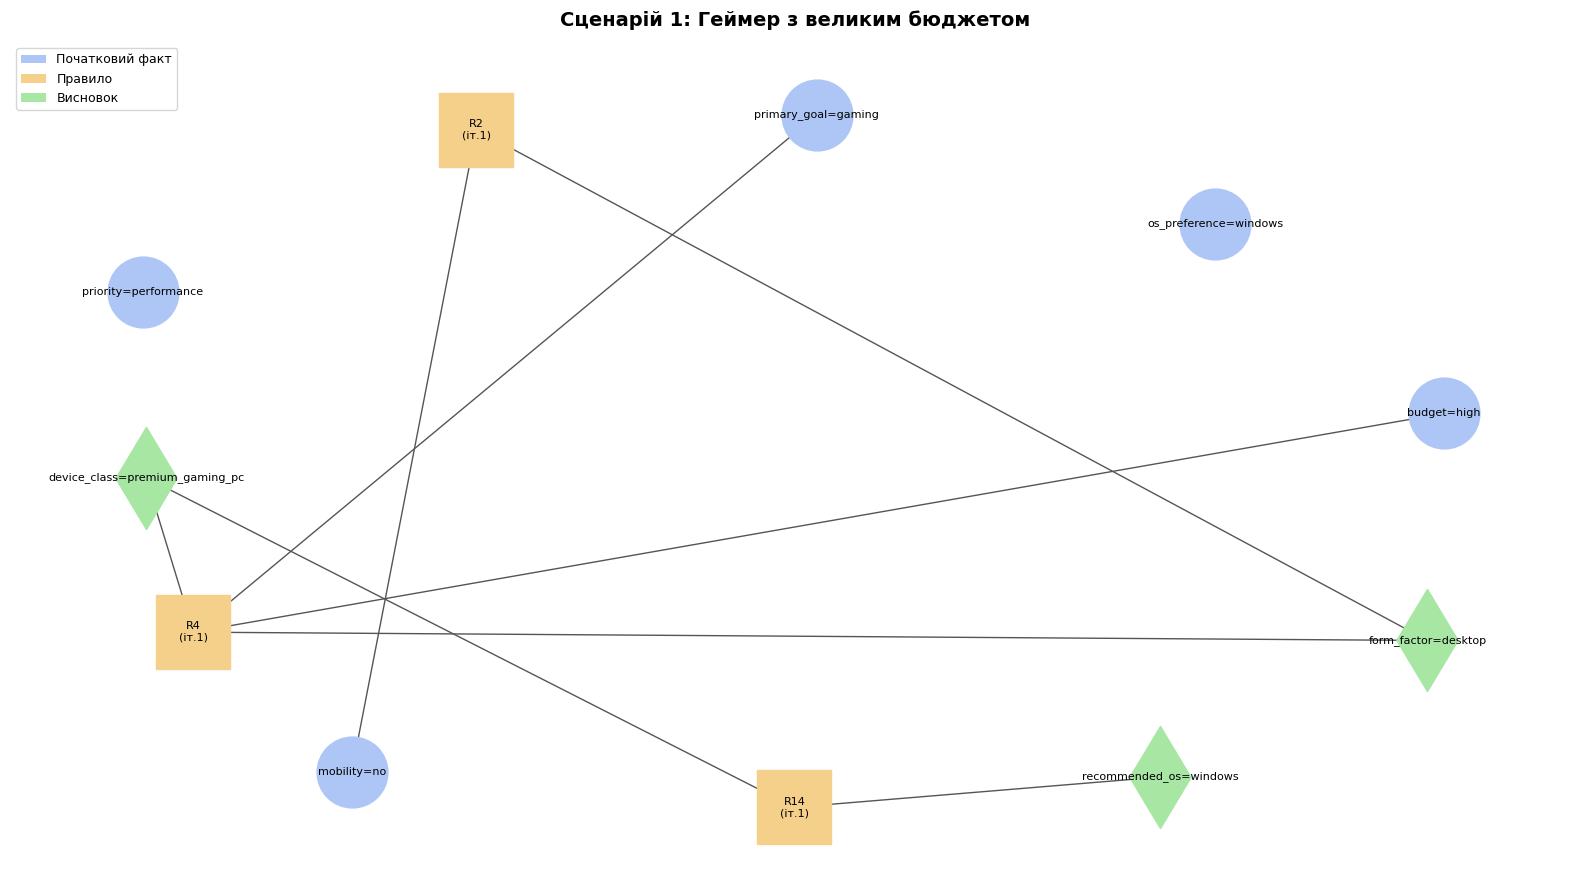

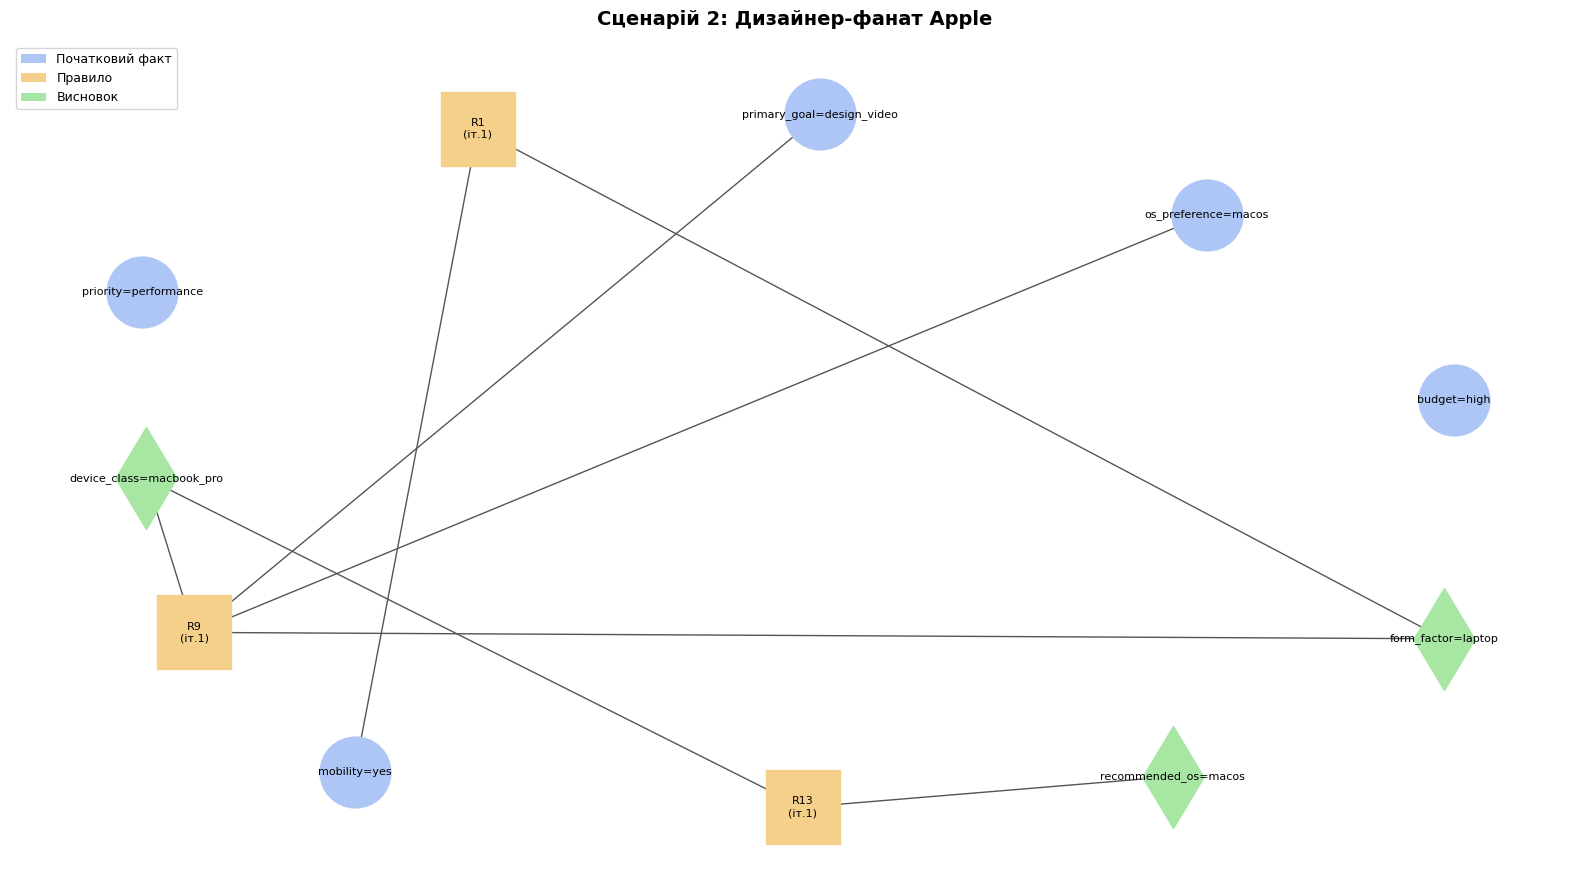

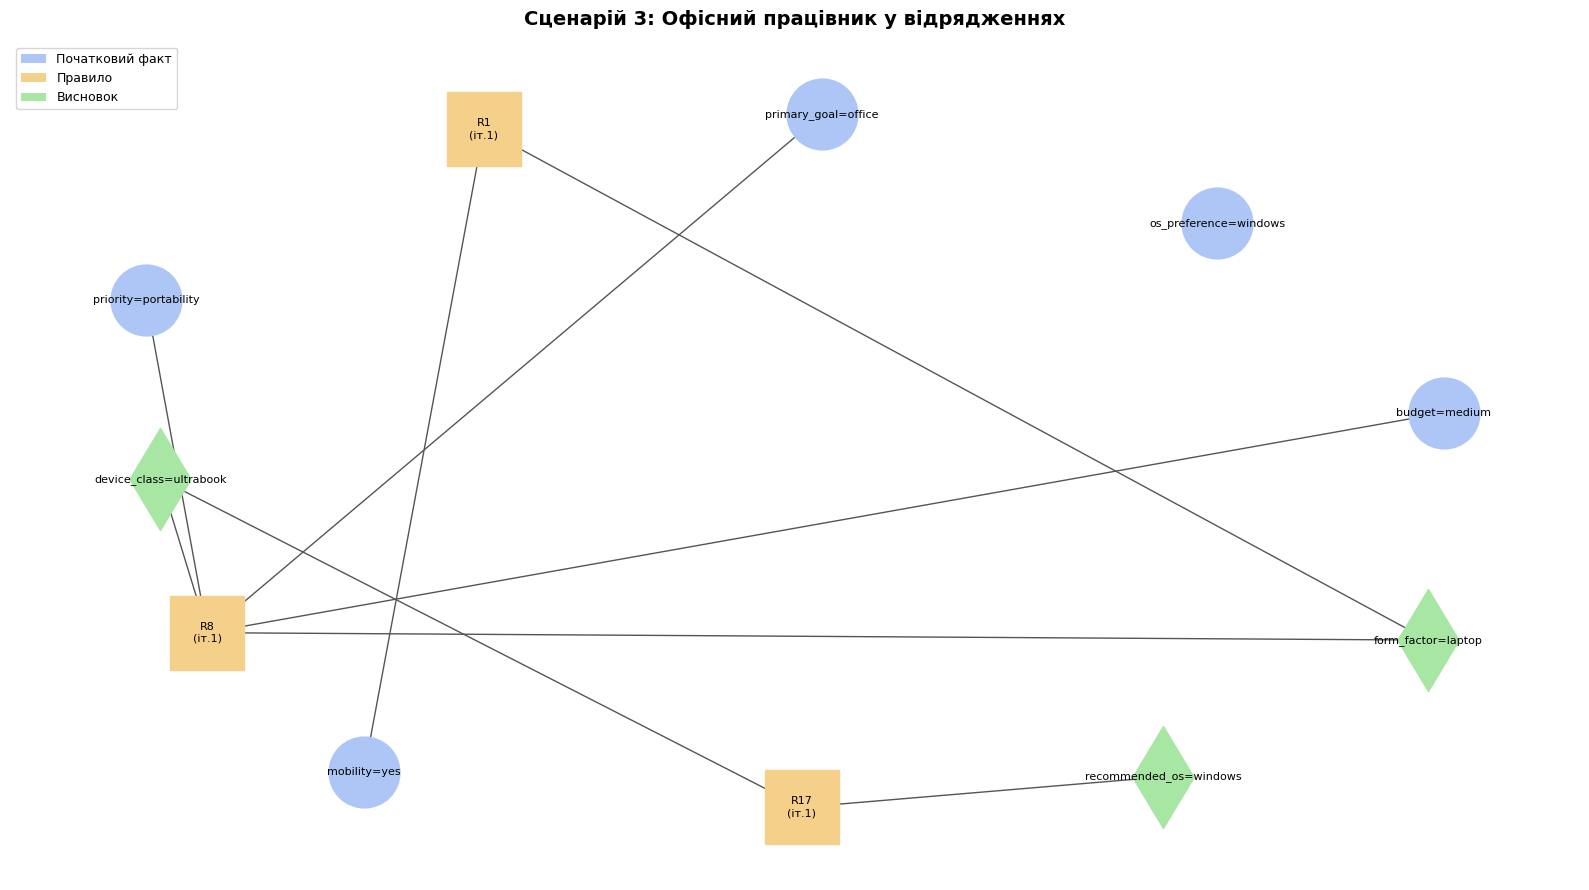

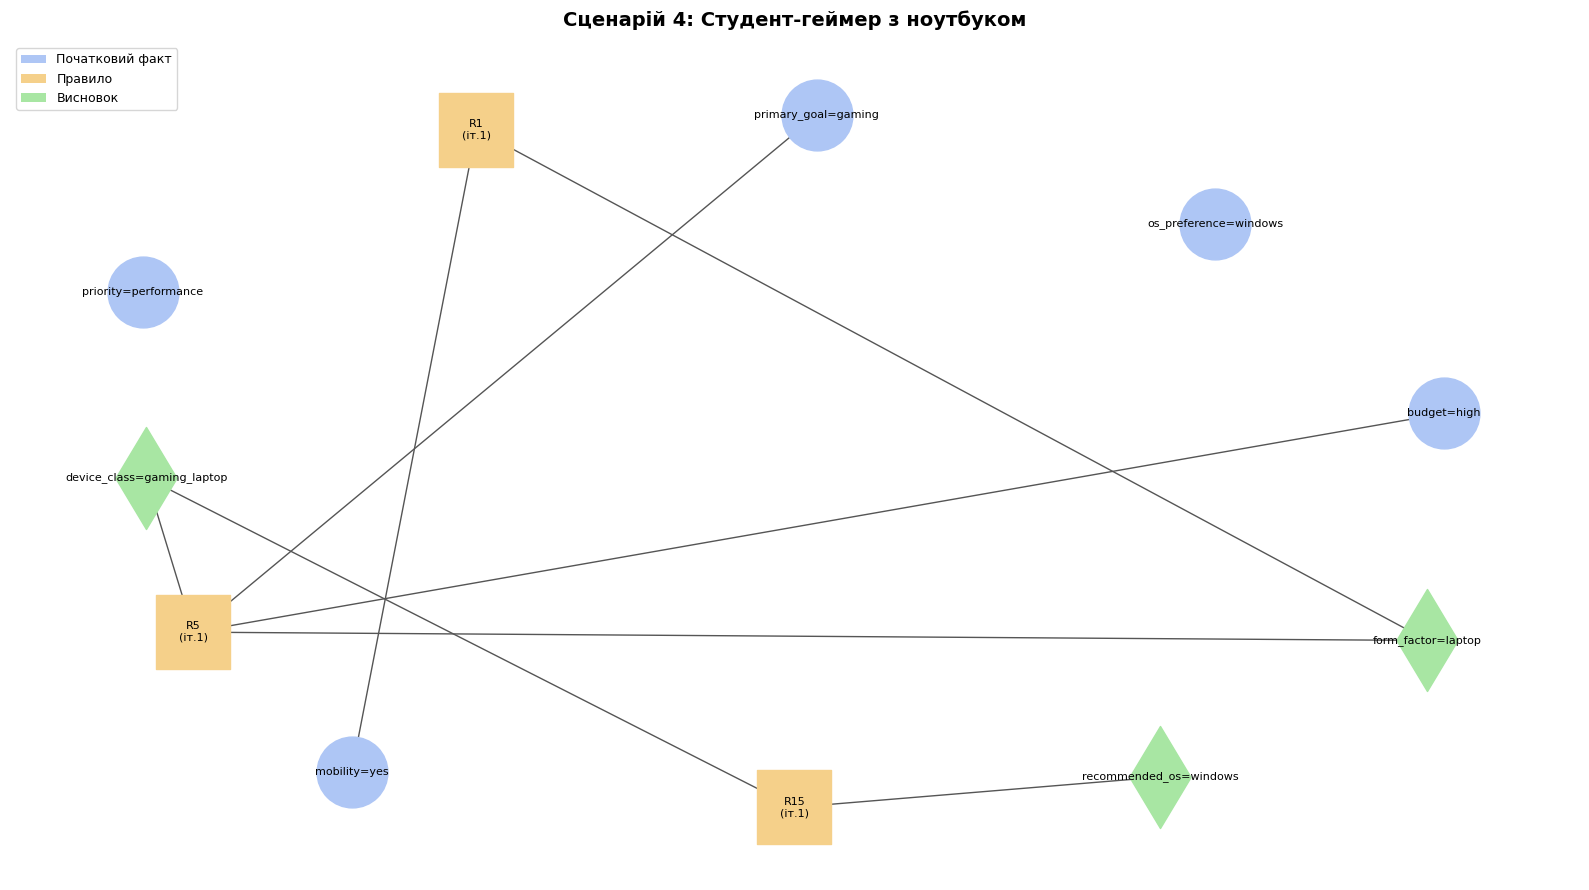

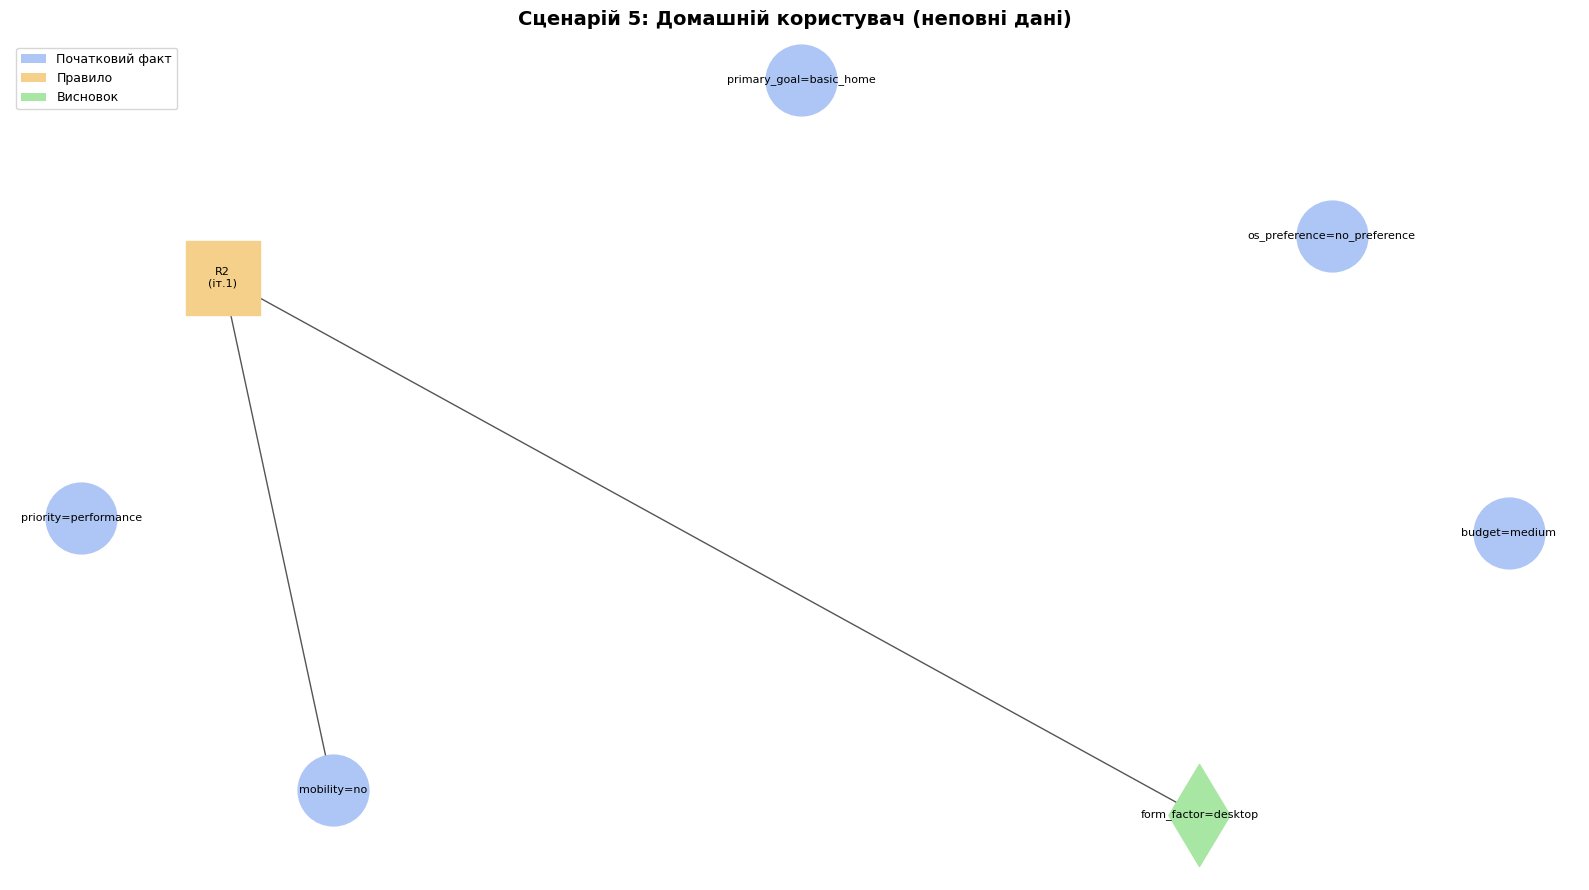

In [15]:
# Завдання 6. Побудова графів для всіх сценаріїв

for result in scenario_results:
    draw_reasoning_graph(result)

## Завдання 7. Проаналізувати отримані результати та зробити висновки

Автоматизований аналіз оцінює:
- покриття сценарію правилами
- наявність конфліктів (один атрибут отримує різні значення від різних правил)
- кінцевий стан фактів

In [16]:
# Завдання 7. Автоматизований аналіз результатів

def analyze_results(scenario_results):
    for result in scenario_results:
        print("\n" + "=" * 70)
        print(result["name"])

        if not result["log"]:
            print("  ⚠ Висновок: жодне правило не спрацювало. "
                  "База правил не покриває цей випадок.")
            continue

        # Пошук конфліктів — один атрибут отримує різні значення
        assignments = {}
        for item in result["log"]:
            key, value = item["conclusion"]
            assignments.setdefault(key, []).append((item["rule"], value))

        conflicts = [
            (key, vals)
            for key, vals in assignments.items()
            if len(set(v for _, v in vals)) > 1
        ]

        if conflicts:
            print("  ⚠ Виявлено конфлікти:")
            for key, vals in conflicts:
                print(f"    Атрибут '{key}' отримував різні значення:")
                for rule_name, value in vals:
                    print(f"      {rule_name} → {value}")
        else:
            print("  ✓ Потенційних конфліктів не виявлено.")

        # Перевірка чи визначені всі цільові атрибути
        targets = ["form_factor", "device_class", "recommended_os"]
        for t in targets:
            val = result["inferred_facts"].get(t, "НЕ ВИЗНАЧЕНО")
            status = "✓" if t in result["inferred_facts"] else "⚠"
            print(f"  {status} {t}: {val}")


print("Аналіз результатів роботи алгоритму:")
analyze_results(scenario_results)

Аналіз результатів роботи алгоритму:

Сценарій 1: Геймер з великим бюджетом
  ✓ Потенційних конфліктів не виявлено.
  ✓ form_factor: desktop
  ✓ device_class: premium_gaming_pc
  ✓ recommended_os: windows

Сценарій 2: Дизайнер-фанат Apple
  ✓ Потенційних конфліктів не виявлено.
  ✓ form_factor: laptop
  ✓ device_class: macbook_pro
  ✓ recommended_os: macos

Сценарій 3: Офісний працівник у відрядженнях
  ✓ Потенційних конфліктів не виявлено.
  ✓ form_factor: laptop
  ✓ device_class: ultrabook
  ✓ recommended_os: windows

Сценарій 4: Студент-геймер з ноутбуком
  ✓ Потенційних конфліктів не виявлено.
  ✓ form_factor: laptop
  ✓ device_class: gaming_laptop
  ✓ recommended_os: windows

Сценарій 5: Домашній користувач (неповні дані)
  ✓ Потенційних конфліктів не виявлено.
  ✓ form_factor: desktop
  ⚠ device_class: НЕ ВИЗНАЧЕНО
  ⚠ recommended_os: НЕ ВИЗНАЧЕНО


## Висновки

1. **Покриття сценаріїв:** База з 17 правил успішно обробляє 4 з 5 сценаріїв, формуючи повний ланцюжок `form_factor → device_class → recommended_os`. Сценарій 5 (базовий домашній ПК з `budget=medium`) демонструє неповноту бази — правило для комбінації `basic_home + desktop + medium` відсутнє.

2. **Ланцюжок міркувань:** Алгоритм прямого висновку коректно побудував багатокрокові ланцюжки: наприклад, у сценарії 2 спочатку визначено `form_factor=laptop` (R1), потім `device_class=macbook_pro` (R9), і нарешті `recommended_os=macos` (R13) — три ітерації у трьох різних циклах.

3. **Відсутність конфліктів:** Правила взаємовиключні завдяки чіткій градації `budget`, `primary_goal` та `form_factor`. Конфліктних ситуацій у поточній базі не виявлено.

4. **Обмеження системи:** Виявлено «сліпу пляму» для `basic_home + desktop` при бюджеті `medium` або `high`. Також система не враховує мультизадачність (наприклад, `gaming + design_video`).

5. **Напрями покращення:**
   - Додати правила для незакритих комбінацій (бюджетні десктопи для дому).
   - Запровадити пріоритети правил для вирішення потенційних конфліктів при розширенні бази.
   - Додати обробку неповних вхідних даних (дефолтні значення атрибутів).